# Item selection heatmap

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Purpose of this notebook
Since we are making claims about how people are building their goals, we want to see if the interface that we are giving them to build their goal might be influencing them. Here we make a heatmap of what goals were selected to see if the pattern with which goals were presented might be affecting their choices. This is for the first pilot of the goal selection experiment.

In [13]:
goal_selections = pd.read_csv('data-processed/goal_selections.csv')

# remove trials with no action_type
goal_selections = goal_selections[goal_selections['action_type'].notna()]

# drop not needed columns
goal_selections = goal_selections.drop(columns=['timestamp', 'position'])

# exclude action_type == 'failed_drop'
goal_selections = goal_selections[goal_selections['action_type'] == 'drop']

goal_selections




,action_type,source_position,shape_type,shade,texture,participant_id
7,drop,23.0,circle,high,dots,pcimzwewtndyjm8hu2zke03i
9,drop,24.0,square,low,stripes,pcimzwewtndyjm8hu2zke03i
11,drop,1.0,square,high,plain,pcimzwewtndyjm8hu2zke03i
19,drop,0.0,triangle,high,dots,pcimzwewtndyjm8hu2zke03i
21,drop,22.0,circle,high,dots,pcimzwewtndyjm8hu2zke03i
...,...,...,...,...,...,...
1335,drop,23.0,square,medium,plain,vdj36tuk4vvcao8sqcjgymb9
1337,drop,23.0,square,medium,plain,vdj36tuk4vvcao8sqcjgymb9
1342,drop,12.0,circle,low,plain,vdj36tuk4vvcao8sqcjgymb9
1346,drop,12.0,circle,low,plain,vdj36tuk4vvcao8sqcjgymb9


<Axes: >

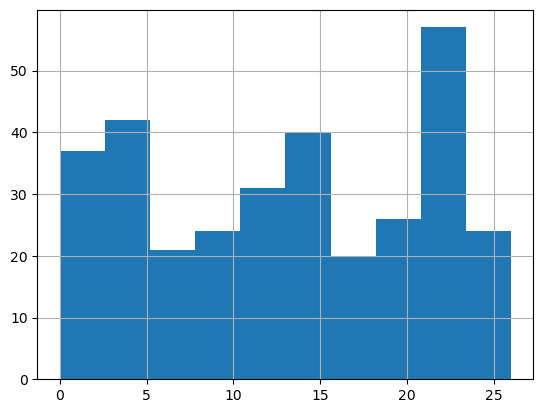

In [14]:
# plot histogam of source_position
goal_selections['source_position'].hist()



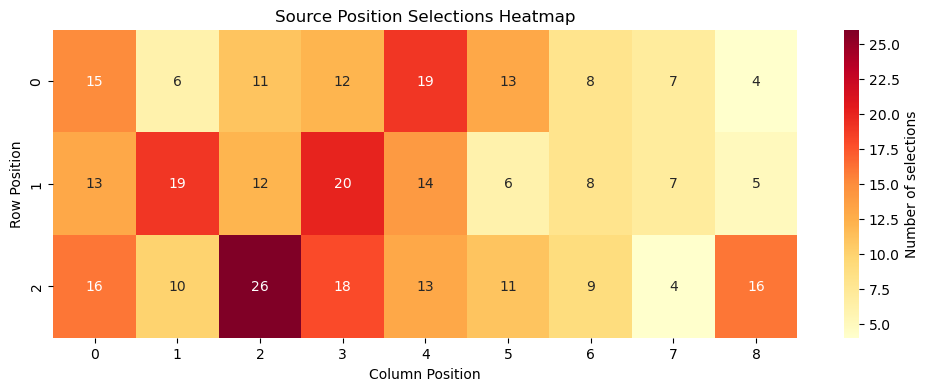

In [16]:
# Create a 3x9 grid of zeros
grid = np.zeros((3, 9))

# Convert source positions to 0-based indices
# If positions start at 1 and go left-to-right, top-to-bottom:
for pos in goal_selections['source_position']:
    if pd.notna(pos):  # Check for NaN values
        pos = int(pos) - 1  # Convert to 0-based index
        row = pos // 9     # Integer division to get row
        col = pos % 9      # Modulo to get column
        grid[row][col] += 1

# Create heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(grid, 
            annot=True,    # Show numbers in cells
            fmt='g',       # Format as integers
            cmap='YlOrRd', # Yellow-Orange-Red colormap
            cbar_kws={'label': 'Number of selections'})

plt.title('Source Position Selections Heatmap')
plt.xlabel('Column Position')
plt.ylabel('Row Position')

# Save and show the plot
plt.savefig('figures/source_position_heatmap.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

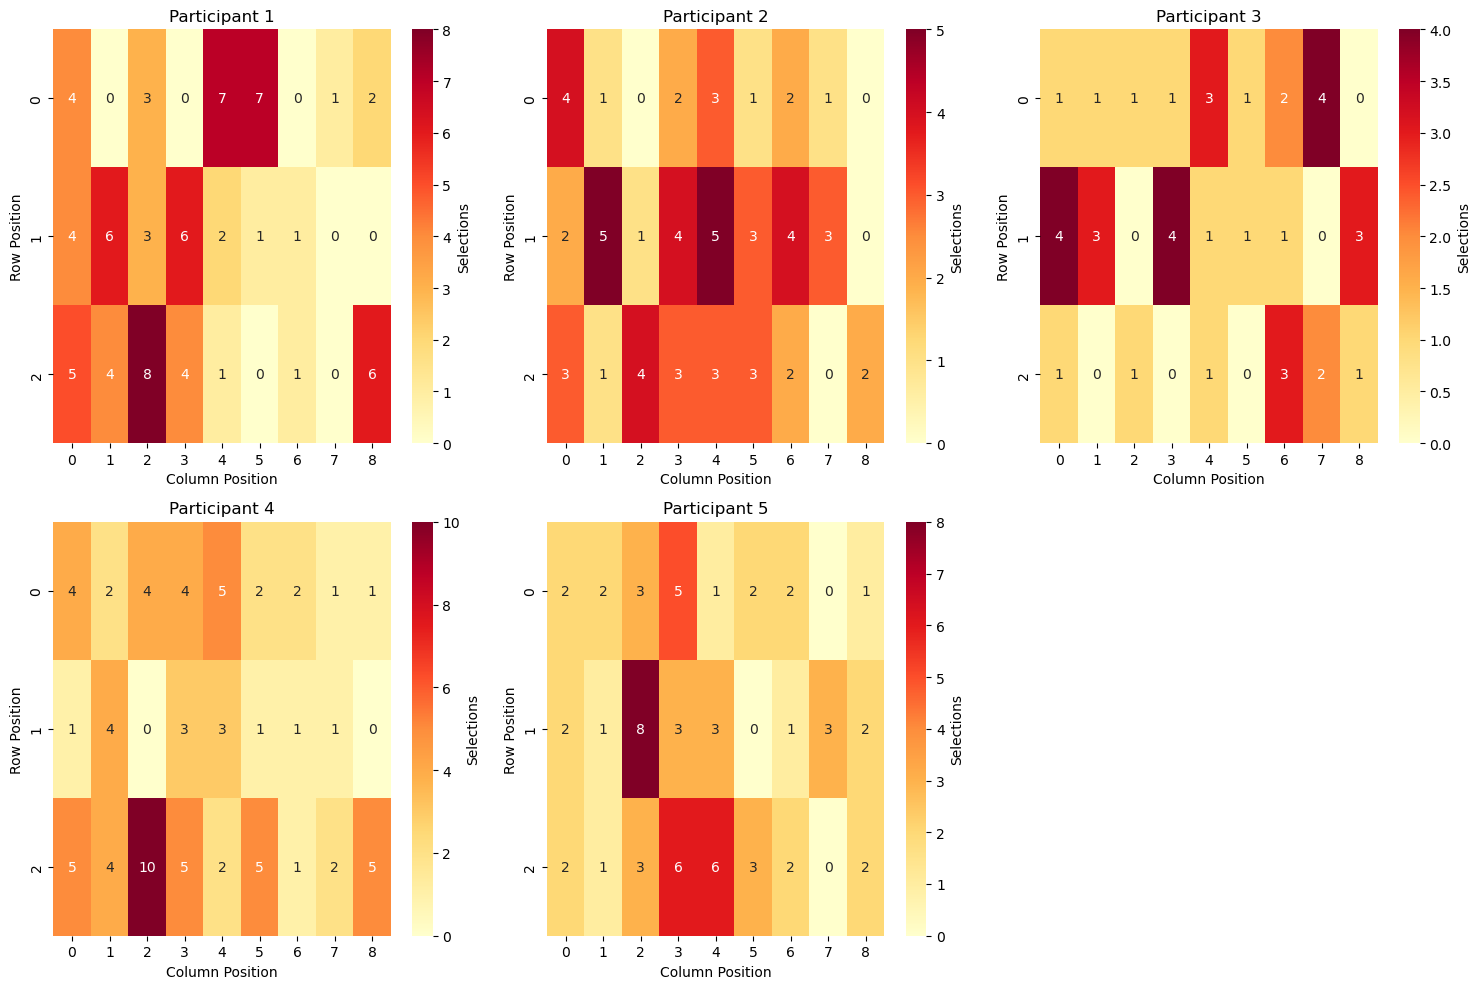

In [17]:
 # Get number of participants
n_participants = goal_selections['participant_id'].nunique()
n_cols = 3  # Number of columns in the subplot grid
n_rows = (n_participants + n_cols - 1) // n_cols  # Calculate needed rows

# Create subplot grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()  # Flatten to make indexing easier

# Create a heatmap for each participant
for idx, (participant_id, participant_data) in enumerate(goal_selections.groupby('participant_id')):
    # Create a 3x9 grid of zeros for this participant
    grid = np.zeros((3, 9))
    
    # Fill the grid with this participant's selections
    for pos in participant_data['source_position']:
        if pd.notna(pos):
            pos = int(pos) - 1
            row = pos // 9
            col = pos % 9
            grid[row][col] += 1
    
    # Create heatmap in the corresponding subplot
    sns.heatmap(grid,
                ax=axes[idx],
                annot=True,
                fmt='g',
                cmap='YlOrRd',
                cbar_kws={'label': 'Selections'})
    
    axes[idx].set_title(f'Participant {idx+1}')
    axes[idx].set_xlabel('Column Position')
    axes[idx].set_ylabel('Row Position')

# Remove any empty subplots
for idx in range(n_participants, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('figures/source_position_heatmap_per_participant.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()